In [1]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join('..')))

from src.load_data_BCICIV import load_all_subjects
from src.train_CNN import train_model_cv
import torch
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import mlflow

np.random.seed(42)
torch.manual_seed(42)


/home/alumno/Desktop/datos/a/Biosignal-ML-Analysis/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# DATA LOAD

In [2]:
data_path = '../datasets/BCICIV_2a_gdf'

data_22 = load_all_subjects(data_path, channels_to_use='all')
data_22_multiband = load_all_subjects(data_path, use_multiband=True, bands=[(8, 12), (13, 30)], channels_to_use='all')
data_11 = load_all_subjects(data_path)
data_11_multiband = load_all_subjects(data_path, use_multiband=True, bands=[(8, 12), (13, 30)])

/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Loaded file: ../datasets/BCICIV_2a_gdf/A01T.gdf


/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Loaded file: ../datasets/BCICIV_2a_gdf/A02T.gdf


/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


...

/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Loaded file: ../datasets/BCICIV_2a_gdf/A08T.gdf


/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Loaded file: ../datasets/BCICIV_2a_gdf/A09T.gdf


/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
/home/alumno/.local/share/uv/python/cpython-3.13.7-l

In [3]:
subjects = data_22['subject_ids'] 

X_22 = data_22['X'] 
y_22 = data_22['y'] 

X_22_multiband = data_22_multiband['X'] 
y_22_multiband = data_22_multiband['y'] 

X_11 = data_11['X'] 
y_11 = data_11['y'] 

X_11_multiband = data_11_multiband['X'] 
y_11_multiband = data_11_multiband['y'] 

# ShallowConvNet

In [4]:
models = {
    'model': [],
    'accuracies': [],
    'name': []
}

model_type = 'shallow'

## Tests with 22 channels

### 22 channels (raw + normalization)

In [5]:
model, test_subject_accuracies = train_model_cv(X_22, y_22, subjects, transforms=[], model_type=model_type, epochs=100, lr=0.0003, patience=20)
models['model'].append(model)
models['accuracies'].append(test_subject_accuracies)
models['name'].append('raw_22')

2026/05/13 14:17:15 INFO mlflow.tracking.fluent: Experiment with name 'BCI_ConvNet' does not exist. Creating a new experiment.
2026/05/13 14:18:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/05/13 14:18:16 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 1 | Subject A01 | Train Acc: 0.9670 | Test Acc: 0.7413


2026/05/13 14:18:22 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/05/13 14:19:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/05/13 14:19:19 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 2 | Subject A02 | Train Acc: 0.9722 | Test Acc: 0.5833


2026/05/13 14:19:24 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/05/13 14:20:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/05/13 14:20:21 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


...

Fold 8 | Subject A08 | Train Acc: 0.9600 | Test Acc: 0.6667


2026/05/13 14:25:24 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/05/13 14:25:28 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/05/13 14:26:22 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  


Fold 9 | Subject A09 | Train Acc: 0.9722 | Test Acc: 0.5833


2026/05/13 14:26:22 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/05/13 14:26:26 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



Mean Subject Test Accuracy: 0.6338 ± 0.0474


### 22 channels + laplacian filter on C3 and C4

In [6]:
model, test_subject_accuracies = train_model_cv(X_22, y_22, subjects, transforms=['laplacian'], model_type=model_type, epochs=100, lr=0.0003, patience=20)
models['model'].append(model)
models['accuracies'].append(test_subject_accuracies)
models['name'].append('laplacian_22')

2026/05/13 14:27:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/05/13 14:27:25 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 1 | Subject A01 | Train Acc: 0.9887 | Test Acc: 0.7622


2026/05/13 14:27:29 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/05/13 14:28:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/05/13 14:28:28 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 2 | Subject A02 | Train Acc: 0.9887 | Test Acc: 0.5764


2026/05/13 14:28:34 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/05/13 14:29:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/05/13 14:29:32 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


...

Fold 8 | Subject A08 | Train Acc: 0.9904 | Test Acc: 0.5972


2026/05/13 14:34:42 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/05/13 14:34:48 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/05/13 14:35:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  


Fold 9 | Subject A09 | Train Acc: 0.9896 | Test Acc: 0.5069


2026/05/13 14:35:45 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/05/13 14:35:49 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



Mean Subject Test Accuracy: 0.5944 ± 0.0722


### 22 channels - only mu band

In [7]:
model, test_subject_accuracies = train_model_cv(X_22_multiband, y_22_multiband, subjects, transforms=['laplacian', 'mu_band'], model_type=model_type, epochs=100, lr=0.0003, patience=20)
models['model'].append(model)
models['accuracies'].append(test_subject_accuracies)
models['name'].append('mu_22')

2026/05/13 14:36:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/05/13 14:36:45 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 1 | Subject A01 | Train Acc: 0.9505 | Test Acc: 0.6713


2026/05/13 14:36:49 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/05/13 14:37:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/05/13 14:37:44 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 2 | Subject A02 | Train Acc: 0.9609 | Test Acc: 0.5069


2026/05/13 14:37:49 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/05/13 14:38:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/05/13 14:38:44 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


...

Fold 8 | Subject A08 | Train Acc: 0.9548 | Test Acc: 0.5694


2026/05/13 14:43:45 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/05/13 14:43:49 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/05/13 14:44:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  


Fold 9 | Subject A09 | Train Acc: 0.9678 | Test Acc: 0.5694


2026/05/13 14:44:47 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/05/13 14:44:51 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



Mean Subject Test Accuracy: 0.5804 ± 0.0574


### 22 channels - mu + beta band

In [8]:
model, test_subject_accuracies = train_model_cv(X_22_multiband, y_22_multiband, subjects, transforms=['laplacian', 'multiband'], model_type=model_type, epochs=100, lr=0.0003, patience=20)
models['model'].append(model)
models['accuracies'].append(test_subject_accuracies)
models['name'].append('multiband_22')

2026/05/13 14:45:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/05/13 14:45:54 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 1 | Subject A01 | Train Acc: 0.9939 | Test Acc: 0.6853


2026/05/13 14:45:58 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/05/13 14:47:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/05/13 14:47:10 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 2 | Subject A02 | Train Acc: 0.9930 | Test Acc: 0.5625


2026/05/13 14:47:14 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/05/13 14:48:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/05/13 14:48:28 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


...

Fold 8 | Subject A08 | Train Acc: 0.9948 | Test Acc: 0.6389


2026/05/13 14:54:48 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/05/13 14:54:52 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/05/13 14:55:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  


Fold 9 | Subject A09 | Train Acc: 0.9957 | Test Acc: 0.4861


2026/05/13 14:55:53 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/05/13 14:55:57 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



Mean Subject Test Accuracy: 0.6021 ± 0.0585


## Tests with 11 channels

### 11 channels (raw + normalization)

In [9]:
model, test_subject_accuracies = train_model_cv(X_11, y_11, subjects, transforms=[], model_type=model_type, epochs=100, lr=0.0003, patience=20)
models['model'].append(model)
models['accuracies'].append(test_subject_accuracies)
models['name'].append('raw_11')

2026/05/13 14:56:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/05/13 14:56:38 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 1 | Subject A01 | Train Acc: 0.9453 | Test Acc: 0.6713


2026/05/13 14:56:42 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/05/13 14:57:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/05/13 14:57:23 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 2 | Subject A02 | Train Acc: 0.9591 | Test Acc: 0.5417


2026/05/13 14:57:27 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/05/13 14:58:07 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/05/13 14:58:07 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


...

Fold 8 | Subject A08 | Train Acc: 0.9339 | Test Acc: 0.6111


2026/05/13 15:01:49 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/05/13 15:01:53 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/05/13 15:02:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  


Fold 9 | Subject A09 | Train Acc: 0.9548 | Test Acc: 0.4931


2026/05/13 15:02:34 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/05/13 15:02:37 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



Mean Subject Test Accuracy: 0.5967 ± 0.0576


### 11 channels + laplacian filter on C3 and C4

In [10]:
model, test_subject_accuracies = train_model_cv(X_11, y_11, subjects, transforms=['laplacian'], model_type=model_type, epochs=100, lr=0.0003, patience=20)
models['model'].append(model)
models['accuracies'].append(test_subject_accuracies)
models['name'].append('laplacian_11')

2026/05/13 15:03:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/05/13 15:03:18 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 1 | Subject A01 | Train Acc: 0.9791 | Test Acc: 0.6783


2026/05/13 15:03:22 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/05/13 15:04:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/05/13 15:04:04 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 2 | Subject A02 | Train Acc: 0.9852 | Test Acc: 0.6528


2026/05/13 15:04:07 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/05/13 15:04:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/05/13 15:04:48 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


...

Fold 8 | Subject A08 | Train Acc: 0.9800 | Test Acc: 0.6250


2026/05/13 15:08:36 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/05/13 15:08:40 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/05/13 15:09:22 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  


Fold 9 | Subject A09 | Train Acc: 0.9809 | Test Acc: 0.5486


2026/05/13 15:09:22 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/05/13 15:09:26 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



Mean Subject Test Accuracy: 0.6298 ± 0.0479


### 11 channels - only mu band

In [11]:
model, test_subject_accuracies = train_model_cv(X_11_multiband, y_11_multiband, subjects, transforms=['laplacian', 'mu_band'], model_type=model_type, epochs=100, lr=0.0003, patience=20)
models['model'].append(model)
models['accuracies'].append(test_subject_accuracies)
models['name'].append('mu_11')

2026/05/13 15:10:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/05/13 15:10:09 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 1 | Subject A01 | Train Acc: 0.9479 | Test Acc: 0.6294


2026/05/13 15:10:12 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/05/13 15:10:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/05/13 15:10:54 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 2 | Subject A02 | Train Acc: 0.9470 | Test Acc: 0.5972


2026/05/13 15:10:58 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/05/13 15:11:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/05/13 15:11:40 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


...

Fold 8 | Subject A08 | Train Acc: 0.9452 | Test Acc: 0.5764


2026/05/13 15:15:31 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/05/13 15:15:35 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/05/13 15:16:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  


Fold 9 | Subject A09 | Train Acc: 0.9409 | Test Acc: 0.5347


2026/05/13 15:16:17 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/05/13 15:16:20 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



Mean Subject Test Accuracy: 0.6136 ± 0.0416


### 11 channels - mu + beta band

In [12]:
model, test_subject_accuracies = train_model_cv(X_11_multiband, y_11_multiband, subjects, transforms=['laplacian', 'multiband'], model_type=model_type, epochs=100, lr=0.0003, patience=20)
models['model'].append(model)
models['accuracies'].append(test_subject_accuracies)
models['name'].append('multiband_11')

2026/05/13 15:17:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/05/13 15:17:17 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 1 | Subject A01 | Train Acc: 0.9896 | Test Acc: 0.6713


2026/05/13 15:17:21 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/05/13 15:18:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/05/13 15:18:18 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 2 | Subject A02 | Train Acc: 0.9939 | Test Acc: 0.6250


2026/05/13 15:18:22 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/05/13 15:19:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/05/13 15:19:19 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


...

Fold 8 | Subject A08 | Train Acc: 0.9930 | Test Acc: 0.5833


2026/05/13 15:24:25 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/05/13 15:24:28 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/05/13 15:25:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  


Fold 9 | Subject A09 | Train Acc: 0.9983 | Test Acc: 0.5278


2026/05/13 15:25:26 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/05/13 15:25:30 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



Mean Subject Test Accuracy: 0.6090 ± 0.0502


## Data Augmentation

### 22 channels + laplace + data augmentation

In [13]:
model, test_subject_accuracies = train_model_cv(X_22, y_22, subjects, transforms=['laplacian'], model_type=model_type, epochs=200, lr=0.0003, patience=20, augment=True)
models['model'].append(model)
models['accuracies'].append(test_subject_accuracies)
models['name'].append('laplacian_22_aug')

Early stopping en epoch 173. Best train loss: 0.2898


2026/05/13 15:27:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/13 15:27:12 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 1 | Subject A01 | Train Acc: 0.8514 | Test Acc: 0.7063


2026/05/13 15:27:20 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
                                                                                                            

Early stopping en epoch 121. Best train loss: 0.2996


...

Early stopping en epoch 128. Best train loss: 0.2900


2026/05/13 15:38:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Fold 9 | Subject A09 | Train Acc: 0.8522 | Test Acc: 0.4931


2026/05/13 15:38:44 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/05/13 15:38:49 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



Mean Subject Test Accuracy: 0.6261 ± 0.0703


### 11 channels + laplace + data augmentation

In [14]:
model, test_subject_accuracies = train_model_cv(X_11, y_11, subjects, transforms=['laplacian'], model_type=model_type, epochs=200, lr=0.0003, patience=20, augment=True)
models['model'].append(model)
models['accuracies'].append(test_subject_accuracies)
models['name'].append('laplacian_11_aug')

Early stopping en epoch 120. Best train loss: 0.3361


2026/05/13 15:39:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/13 15:39:42 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 1 | Subject A01 | Train Acc: 0.8349 | Test Acc: 0.7273


2026/05/13 15:39:48 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
                                                                                                           

Early stopping en epoch 89. Best train loss: 0.3394


...

Early stopping en epoch 119. Best train loss: 0.3414


2026/05/13 15:47:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Fold 9 | Subject A09 | Train Acc: 0.8191 | Test Acc: 0.5694


2026/05/13 15:47:16 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/05/13 15:47:20 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



Mean Subject Test Accuracy: 0.6322 ± 0.0537


## Visualization

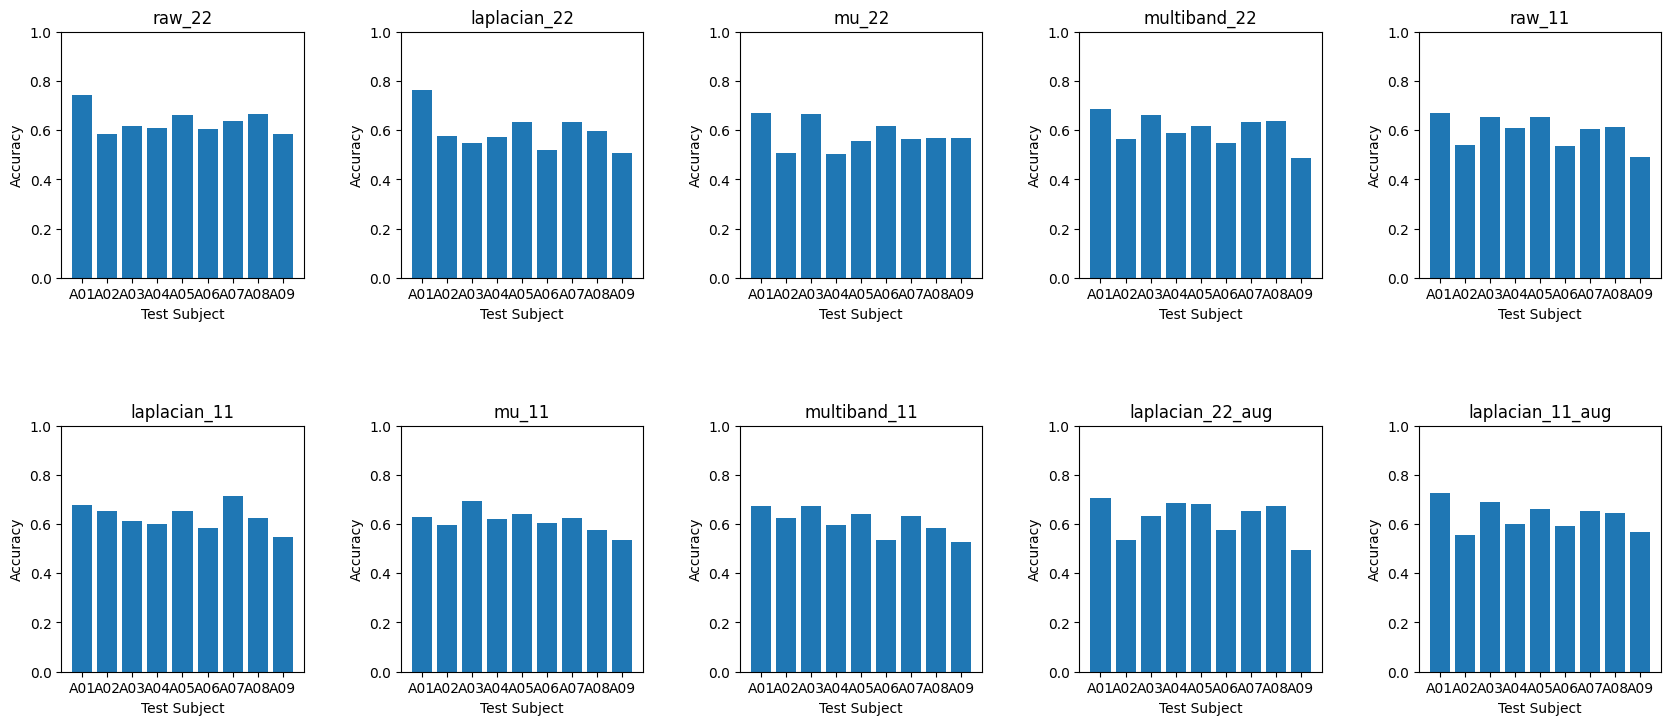

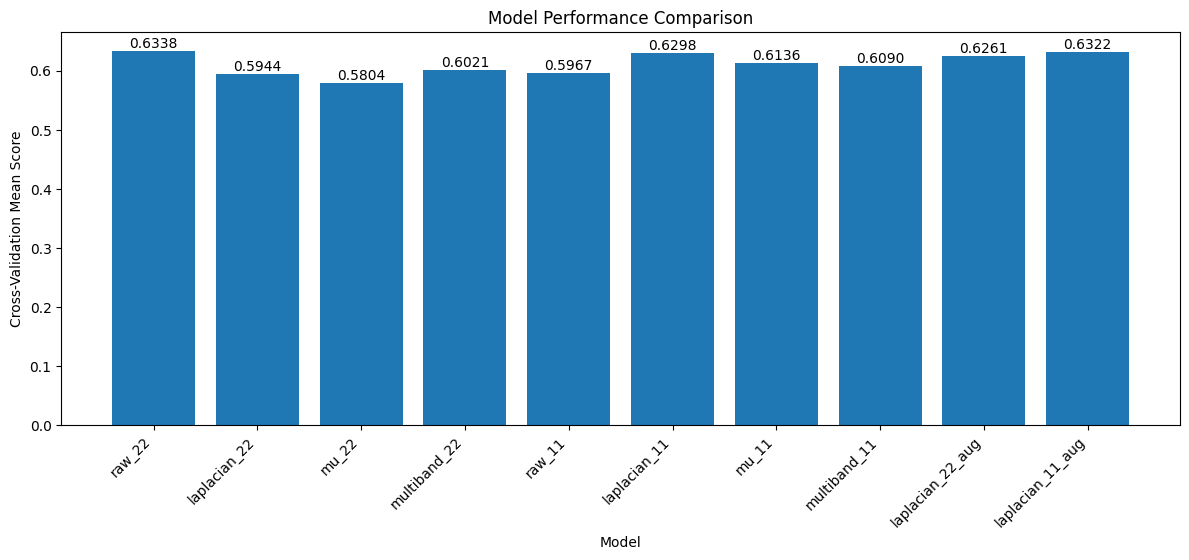

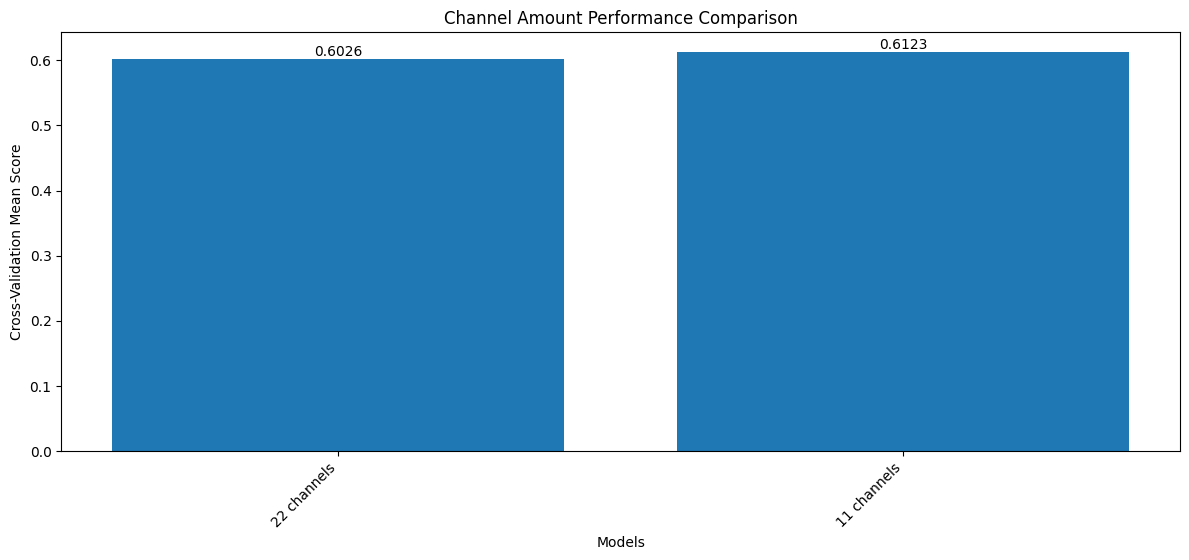

In [15]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for i, (name, accuracies) in enumerate(zip(models['name'], models['accuracies'])):
    ax = axes[i // 5, i % 5]
    ax.bar(np.unique(subjects), accuracies)
    ax.set_title(name)
    ax.set_xlabel('Test Subject')
    ax.set_ylabel('Accuracy')
    ax.set_ylim(0, 1)

plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.9, 
                    wspace=0.4, 
                    hspace=0.6)



accs = [] 

for acc in models['accuracies']:
    accs.append(np.mean(acc))

plt.figure(figsize=(12, 6))
bars = plt.bar(models['name'], accs)
plt.xlabel('Model')
plt.ylabel('Cross-Validation Mean Score')
plt.title('Model Performance Comparison')
plt.bar_label(bars, fmt="%.4f")
plt.xticks(rotation=45, ha='right')
plt.tight_layout(rect=[0, 0, 1, 0.95],)


acc_11_ch = np.mean(accs[4:8])
acc_22_ch = np.mean(accs[:4])

plt.figure(figsize=(12, 6))
bars = plt.bar(['22 channels', '11 channels'], [acc_22_ch, acc_11_ch])
plt.xlabel('Models')
plt.ylabel('Cross-Validation Mean Score')
plt.title('Channel Amount Performance Comparison')
plt.bar_label(bars, fmt="%.4f")
plt.xticks(rotation=45, ha='right')
plt.tight_layout(rect=[0, 0, 1, 0.95],)

# DeepConvNet

In [16]:
models = {
    'model': [],
    'accuracies': [],
    'name': []
}

model_type = 'deep'

## Tests with 22 channels

### 22 channels (raw + normalization)

In [17]:
model, test_subject_accuracies = train_model_cv(X_22, y_22, subjects, transforms=[], model_type=model_type, epochs=100, lr=0.0003, patience=20)
models['model'].append(model)
models['accuracies'].append(test_subject_accuracies)
models['name'].append('raw_22')

2026/05/13 15:48:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/05/13 15:48:16 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 1 | Subject A01 | Train Acc: 0.9870 | Test Acc: 0.5874


2026/05/13 15:48:20 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/05/13 15:49:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/05/13 15:49:14 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 2 | Subject A02 | Train Acc: 0.9887 | Test Acc: 0.5486


2026/05/13 15:49:19 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/05/13 15:50:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  


...

Fold 8 | Subject A08 | Train Acc: 0.9861 | Test Acc: 0.5278


2026/05/13 15:55:13 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/05/13 15:55:19 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/05/13 15:56:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  


Fold 9 | Subject A09 | Train Acc: 0.9922 | Test Acc: 0.4931


2026/05/13 15:56:14 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/05/13 15:56:19 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



Mean Subject Test Accuracy: 0.5603 ± 0.0398


### 22 channels + laplacian filter on C3 and C4

In [18]:
model, test_subject_accuracies = train_model_cv(X_22, y_22, subjects, transforms=['laplacian'], model_type=model_type, epochs=100, lr=0.0003, patience=20)
models['model'].append(model)
models['accuracies'].append(test_subject_accuracies)
models['name'].append('laplacian_22')

2026/05/13 15:57:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/05/13 15:57:15 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 1 | Subject A01 | Train Acc: 0.9930 | Test Acc: 0.5524


2026/05/13 15:57:19 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/05/13 15:58:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/05/13 15:58:15 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 2 | Subject A02 | Train Acc: 0.9878 | Test Acc: 0.5069


2026/05/13 15:58:19 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/05/13 15:59:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/05/13 15:59:14 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


...

Fold 8 | Subject A08 | Train Acc: 0.9913 | Test Acc: 0.5833


2026/05/13 16:04:15 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/05/13 16:04:20 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/05/13 16:05:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  


Fold 9 | Subject A09 | Train Acc: 0.9887 | Test Acc: 0.5347


2026/05/13 16:05:17 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/05/13 16:05:21 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



Mean Subject Test Accuracy: 0.5572 ± 0.0282


### 22 channels - only mu band

In [19]:
model, test_subject_accuracies = train_model_cv(X_22_multiband, y_22_multiband, subjects, transforms=['laplacian', 'mu_band'], model_type=model_type, epochs=100, lr=0.0003, patience=20)
models['model'].append(model)
models['accuracies'].append(test_subject_accuracies)
models['name'].append('mu_22')

2026/05/13 16:06:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/05/13 16:06:19 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 1 | Subject A01 | Train Acc: 0.9878 | Test Acc: 0.5524


2026/05/13 16:06:23 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/05/13 16:07:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/05/13 16:07:20 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 2 | Subject A02 | Train Acc: 0.9939 | Test Acc: 0.4931


2026/05/13 16:07:24 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/05/13 16:08:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/05/13 16:08:21 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


...

Fold 8 | Subject A08 | Train Acc: 0.9861 | Test Acc: 0.5278


2026/05/13 16:13:26 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/05/13 16:13:30 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/05/13 16:14:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  


Fold 9 | Subject A09 | Train Acc: 0.9930 | Test Acc: 0.5625


2026/05/13 16:14:29 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/05/13 16:14:34 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



Mean Subject Test Accuracy: 0.5696 ± 0.0449


### 22 channels - mu + beta band

In [20]:
model, test_subject_accuracies = train_model_cv(X_22_multiband, y_22_multiband, subjects, transforms=['laplacian', 'multiband'], model_type=model_type, epochs=100, lr=0.0003, patience=20)
models['model'].append(model)
models['accuracies'].append(test_subject_accuracies)
models['name'].append('multiband_22')

2026/05/13 16:15:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/05/13 16:15:36 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 1 | Subject A01 | Train Acc: 0.9896 | Test Acc: 0.5594


2026/05/13 16:15:41 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/05/13 16:16:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/05/13 16:16:47 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 2 | Subject A02 | Train Acc: 0.9887 | Test Acc: 0.5694


2026/05/13 16:16:52 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/05/13 16:17:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/05/13 16:17:55 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


...

Fold 8 | Subject A08 | Train Acc: 0.9896 | Test Acc: 0.6181


2026/05/13 16:23:21 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/05/13 16:23:26 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/05/13 16:24:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  


Fold 9 | Subject A09 | Train Acc: 0.9896 | Test Acc: 0.5069


2026/05/13 16:24:27 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/05/13 16:24:33 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



Mean Subject Test Accuracy: 0.5533 ± 0.0369


## Tests with 11 channels

### 11 channels (raw + normalization)

In [21]:
model, test_subject_accuracies = train_model_cv(X_11, y_11, subjects, transforms=[], model_type=model_type, epochs=100, lr=0.0003, patience=20)
models['model'].append(model)
models['accuracies'].append(test_subject_accuracies)
models['name'].append('raw_11')

2026/05/13 16:25:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/05/13 16:25:18 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 1 | Subject A01 | Train Acc: 0.9904 | Test Acc: 0.6154


2026/05/13 16:25:22 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/05/13 16:26:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/05/13 16:26:06 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 2 | Subject A02 | Train Acc: 0.9878 | Test Acc: 0.5417


2026/05/13 16:26:10 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/05/13 16:26:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/05/13 16:26:54 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


...

Fold 8 | Subject A08 | Train Acc: 0.9870 | Test Acc: 0.6111


2026/05/13 16:31:02 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/05/13 16:31:06 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/05/13 16:31:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  


Fold 9 | Subject A09 | Train Acc: 0.9861 | Test Acc: 0.5000


2026/05/13 16:31:51 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/05/13 16:31:54 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



Mean Subject Test Accuracy: 0.5680 ± 0.0416


### 11 channels + laplacian filter on C3 and C4

In [22]:
model, test_subject_accuracies = train_model_cv(X_11, y_11, subjects, transforms=['laplacian'], model_type=model_type, epochs=100, lr=0.0003, patience=20)
models['model'].append(model)
models['accuracies'].append(test_subject_accuracies)
models['name'].append('laplacian_11')

2026/05/13 16:32:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/05/13 16:32:39 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 1 | Subject A01 | Train Acc: 0.9844 | Test Acc: 0.6643


2026/05/13 16:32:43 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/05/13 16:33:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/05/13 16:33:29 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 2 | Subject A02 | Train Acc: 0.9835 | Test Acc: 0.5694


2026/05/13 16:33:34 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/05/13 16:34:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/05/13 16:34:20 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


...

Fold 8 | Subject A08 | Train Acc: 0.9896 | Test Acc: 0.6389


2026/05/13 16:38:27 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/05/13 16:38:34 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/05/13 16:39:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  


Fold 9 | Subject A09 | Train Acc: 0.9904 | Test Acc: 0.4375


2026/05/13 16:39:20 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/05/13 16:39:24 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



Mean Subject Test Accuracy: 0.5866 ± 0.0613


### 11 channels - only mu band

In [23]:
model, test_subject_accuracies = train_model_cv(X_11_multiband, y_11_multiband, subjects, transforms=['laplacian', 'mu_band'], model_type=model_type, epochs=100, lr=0.0003, patience=20)
models['model'].append(model)
models['accuracies'].append(test_subject_accuracies)
models['name'].append('mu_11')

2026/05/13 16:40:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/05/13 16:40:10 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 1 | Subject A01 | Train Acc: 0.9948 | Test Acc: 0.5734


2026/05/13 16:40:13 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/05/13 16:40:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/05/13 16:40:58 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 2 | Subject A02 | Train Acc: 0.9878 | Test Acc: 0.5417


2026/05/13 16:41:04 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/05/13 16:41:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/05/13 16:41:50 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


...

Fold 8 | Subject A08 | Train Acc: 0.9904 | Test Acc: 0.5139


2026/05/13 16:46:16 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/05/13 16:46:20 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/05/13 16:47:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  


Fold 9 | Subject A09 | Train Acc: 0.9904 | Test Acc: 0.5000


2026/05/13 16:47:08 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/05/13 16:47:12 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



Mean Subject Test Accuracy: 0.5773 ± 0.0539


### 11 channels - mu + beta band

In [24]:
model, test_subject_accuracies = train_model_cv(X_11_multiband, y_11_multiband, subjects, transforms=['laplacian', 'multiband'], model_type=model_type, epochs=100, lr=0.0003, patience=20)
models['model'].append(model)
models['accuracies'].append(test_subject_accuracies)
models['name'].append('multiband_11')

2026/05/13 16:48:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/05/13 16:48:12 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 1 | Subject A01 | Train Acc: 0.9887 | Test Acc: 0.6014


2026/05/13 16:48:18 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/05/13 16:49:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/05/13 16:49:17 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 2 | Subject A02 | Train Acc: 0.9913 | Test Acc: 0.5625


2026/05/13 16:49:21 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/05/13 16:50:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/05/13 16:50:20 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


...

Fold 8 | Subject A08 | Train Acc: 0.9922 | Test Acc: 0.5625


2026/05/13 16:55:35 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/05/13 16:55:39 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/05/13 16:56:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  


Fold 9 | Subject A09 | Train Acc: 0.9887 | Test Acc: 0.4931


2026/05/13 16:56:38 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/05/13 16:56:42 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



Mean Subject Test Accuracy: 0.5773 ± 0.0420


## Data Augmentation

### 22 channels + laplace + data augmentation

In [25]:
model, test_subject_accuracies = train_model_cv(X_22, y_22, subjects, transforms=['laplacian'], model_type=model_type, epochs=200, lr=0.0003, patience=20, augment=True)
models['model'].append(model)
models['accuracies'].append(test_subject_accuracies)
models['name'].append('laplacian_22_aug')

Early stopping en epoch 166. Best train loss: 0.2742


2026/05/13 16:58:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/13 16:58:27 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 1 | Subject A01 | Train Acc: 0.8514 | Test Acc: 0.4895


2026/05/13 16:58:33 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
                                                                                                            

Early stopping en epoch 198. Best train loss: 0.2563


...

Early stopping en epoch 186. Best train loss: 0.2627


2026/05/13 17:13:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Fold 9 | Subject A09 | Train Acc: 0.8357 | Test Acc: 0.5417


2026/05/13 17:13:46 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/05/13 17:13:50 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



Mean Subject Test Accuracy: 0.5355 ± 0.0219


### 11 channels + laplace + data augmentation

In [26]:
model, test_subject_accuracies = train_model_cv(X_11, y_11, subjects, transforms=['laplacian'], model_type=model_type, epochs=200, lr=0.0003, patience=20, augment=True)
models['model'].append(model)
models['accuracies'].append(test_subject_accuracies)
models['name'].append('laplacian_11_aug')

Early stopping en epoch 132. Best train loss: 0.3314


2026/05/13 17:14:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/13 17:14:57 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 1 | Subject A01 | Train Acc: 0.8288 | Test Acc: 0.6084


2026/05/13 17:15:04 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
                                                                                                            

Early stopping en epoch 188. Best train loss: 0.2627


...

Early stopping en epoch 165. Best train loss: 0.2970


2026/05/13 17:27:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Fold 9 | Subject A09 | Train Acc: 0.8496 | Test Acc: 0.5069


2026/05/13 17:27:20 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/05/13 17:27:25 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



Mean Subject Test Accuracy: 0.5719 ± 0.0463


## Visualization

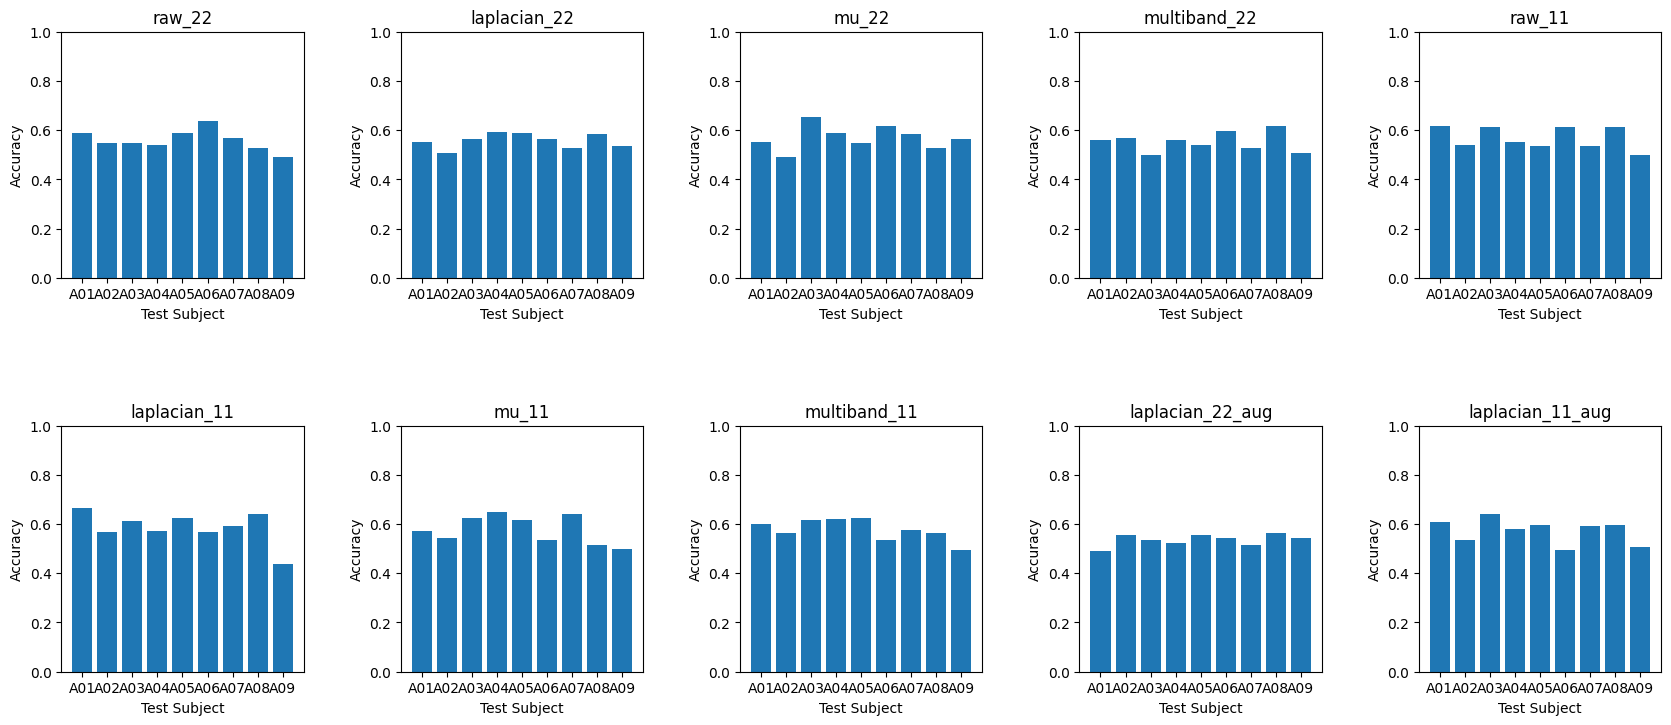

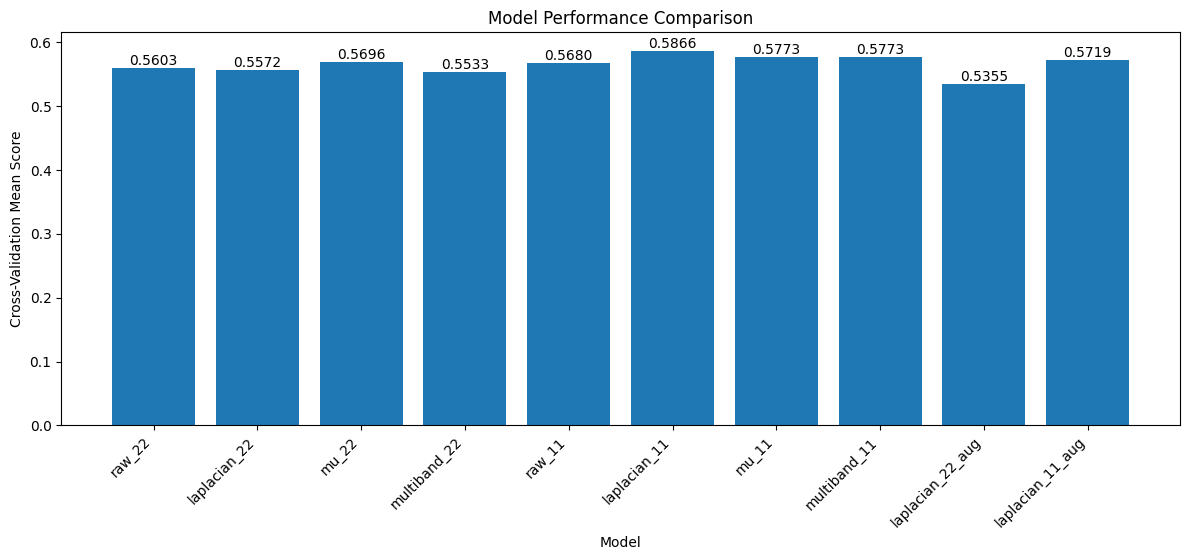

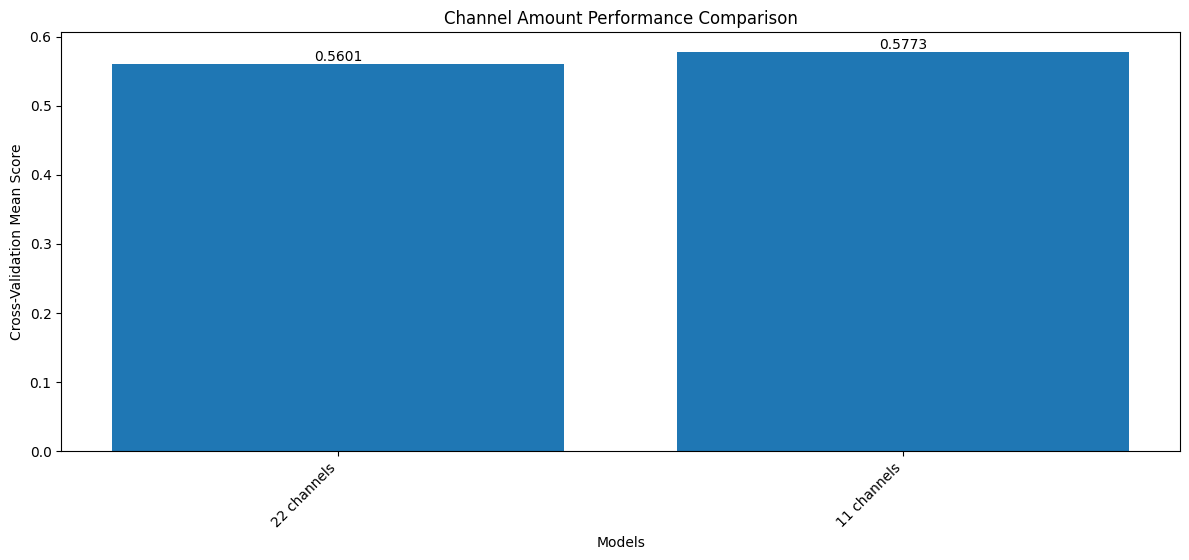

In [27]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for i, (name, accuracies) in enumerate(zip(models['name'], models['accuracies'])):
    ax = axes[i // 5, i % 5]
    ax.bar(np.unique(subjects), accuracies)
    ax.set_title(name)
    ax.set_xlabel('Test Subject')
    ax.set_ylabel('Accuracy')
    ax.set_ylim(0, 1)

plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.9, 
                    wspace=0.4, 
                    hspace=0.6)



accs = [] 

for acc in models['accuracies']:
    accs.append(np.mean(acc))

plt.figure(figsize=(12, 6))
bars = plt.bar(models['name'], accs)
plt.xlabel('Model')
plt.ylabel('Cross-Validation Mean Score')
plt.title('Model Performance Comparison')
plt.bar_label(bars, fmt="%.4f")
plt.xticks(rotation=45, ha='right')
plt.tight_layout(rect=[0, 0, 1, 0.95],)

acc_11_ch = np.mean(accs[4:8])
acc_22_ch = np.mean(accs[:4])

plt.figure(figsize=(12, 6))
bars = plt.bar(['22 channels', '11 channels'], [acc_22_ch, acc_11_ch])
plt.xlabel('Models')
plt.ylabel('Cross-Validation Mean Score')
plt.title('Channel Amount Performance Comparison')
plt.bar_label(bars, fmt="%.4f")
plt.xticks(rotation=45, ha='right')
plt.tight_layout(rect=[0, 0, 1, 0.95],)